# C2CP canonical pathway coverage analysis

💡 **Environment:** `clamp-analyses`  

Analyzes the proportion of canonical pathways (C2CP) that are represented in CLAMPfull_C2CP models
trained with different random-sampling coverage settings (rs1%, rs5%, rs10%).

In [47]:
library(here)
library(ggplot2)
library(dplyr)

## Define GetCLAMPPathwayCoverage

In [48]:
GetCLAMPPathwayCoverage <- function(clamp.results, fdr.cutoff = 0.05, auc.cutoff = 0.6) {
  # Calculates the proportion of canonical pathways in the CLAMP prior
  # information matrix (C) that are significantly associated with at least
  # one latent variable (LV), the proportion of LVs with a pathway
  # associated, and the number of significant pathways per LV.
  #
  # Adapted from GetPathwayCoverage (J. Taroni 2018) for CLAMP models.
  # Key differences from PLIER:
  #   - summary column for LV is 'LV'    (PLIER uses 'LV index')
  #   - summary column for p-value is 'p_value' (PLIER uses 'p.value')
  #   - an additional AUC threshold is supported
  #
  # Args:
  #   clamp.results: output of CLAMPfull() -- a list containing at minimum
  #                  $U (pathways x LVs coefficient matrix),
  #                  $C (genes x pathways prior info matrix),
  #                  $summary (data.frame with columns pathway, LV, AUC,
  #                            p_value, FDR, npos, nneg)
  #   fdr.cutoff:    FDR threshold for significance (default 0.05)
  #   auc.cutoff:    AUC threshold for significance (default 0.6)
  #
  # Returns:
  #   A list with:
  #     pathway:           proportion of input pathways covered (>=1 sig LV)
  #     lv:                proportion of LVs with >=1 sig pathway
  #     sig.pathway.by.lv: number of significant pathways / number of LVs

  summary.df     <- clamp.results$summary
  input.pathways <- colnames(clamp.results$C)   # all pathways supplied as prior
  num.lvs        <- ncol(clamp.results$U)        # total number of LVs

  # Filter to significant pathway-LV associations
  sig.df <- summary.df[summary.df$FDR < fdr.cutoff & summary.df$AUC > auc.cutoff, ]

  sig.pathways <- unique(sig.df$pathway)
  sig.lvs      <- unique(sig.df$LV)

  return.list <- list()

  # Proportion of input pathways that have >=1 significantly associated LV
  return.list$pathway           <- length(sig.pathways) / length(input.pathways)

  # Proportion of LVs that have >=1 significantly associated pathway
  return.list$lv                <- length(sig.lvs) / num.lvs

  # Number of covered pathways per LV
  return.list$sig.pathway.by.lv <- length(sig.pathways) / num.lvs

  return(return.list)
}

## Load CLAMPfull_C2CP models and compute coverage

In [49]:
output_dir <- here("output/archs4")

# Define available models: (coverage %, seed)
model_specs <- list(
  list(coverage = 1,  seed = 1),
  list(coverage = 1,  seed = 2),
  list(coverage = 1,  seed = 3),
  list(coverage = 5,  seed = 1),
  list(coverage = 5,  seed = 2),
  list(coverage = 5,  seed = 3),
  list(coverage = 10, seed = 1),
  list(coverage = 10, seed = 2)
)

results <- lapply(model_specs, function(spec) {
  path <- file.path(
    output_dir,
    sprintf("c2cp_coverage_rs%d_seed_%d", spec$coverage, spec$seed),
    "CLAMPfull_C2CP.rds"
  )

  if (!file.exists(path)) {
    warning("File not found: ", path)
    return(NULL)
  }

  model    <- readRDS(path)
  coverage <- GetCLAMPPathwayCoverage(model, fdr.cutoff = 0.1, auc.cutoff = 0.6)

  data.frame(
    name               = sprintf("c2cp_coverage_rs%d_seed_%d", spec$coverage, spec$seed),
    coverage_pct       = spec$coverage,
    seed               = spec$seed,
    n_input_pathways   = length(colnames(model$C)),
    n_lvs              = ncol(model$U),
    prop_pathway       = coverage$pathway,
    prop_lv            = coverage$lv,
    sig_pathway_per_lv = coverage$sig.pathway.by.lv,
    stringsAsFactors   = FALSE
  )
})

results_df <- do.call(rbind, Filter(Negate(is.null), results))
rownames(results_df) <- NULL

# Add full model (all samples, 1 repetition)
full_model_path <- file.path(output_dir, "archs4_CLAMP_C2CP.rds")
if (file.exists(full_model_path)) {
  full_model    <- readRDS(full_model_path)
  full_coverage <- GetCLAMPPathwayCoverage(full_model, fdr.cutoff = 0.1, auc.cutoff = 0.6)
  full_row <- data.frame(
    name               = "archs4_CLAMP_C2CP",
    coverage_pct       = 100,
    seed               = 1,
    n_input_pathways   = length(colnames(full_model$C)),
    n_lvs              = ncol(full_model$U),
    prop_pathway       = full_coverage$pathway,
    prop_lv            = full_coverage$lv,
    sig_pathway_per_lv = full_coverage$sig.pathway.by.lv,
    stringsAsFactors   = FALSE
  )
  results_df <- rbind(results_df, full_row)
} else {
  warning("Full model not found: ", full_model_path)
}

rownames(results_df) <- NULL
print(results_df)

                       name coverage_pct seed n_input_pathways n_lvs
1  c2cp_coverage_rs1_seed_1            1    1             3109  1084
2  c2cp_coverage_rs1_seed_2            1    2             3109   936
3  c2cp_coverage_rs1_seed_3            1    3             3109  1146
4  c2cp_coverage_rs5_seed_1            5    1             3109  2312
5  c2cp_coverage_rs5_seed_2            5    2             3109  2324
6  c2cp_coverage_rs5_seed_3            5    3             3109  1586
7 c2cp_coverage_rs10_seed_1           10    1             3109  1136
8 c2cp_coverage_rs10_seed_2           10    2             3109  2546
9         archs4_CLAMP_C2CP          100    1             3109  2366
  prop_pathway   prop_lv sig_pathway_per_lv
1    0.2097137 0.6051661          0.6014760
2    0.2071406 0.6164530          0.6880342
3    0.2061756 0.5427574          0.5593368
4    0.1698295 0.2201557          0.2283737
5    0.1646832 0.2108434          0.2203098
6    0.1820521 0.3240858          0.3568726
7 

## Boxplot: pathway coverage per % (ordered by descending coverage)

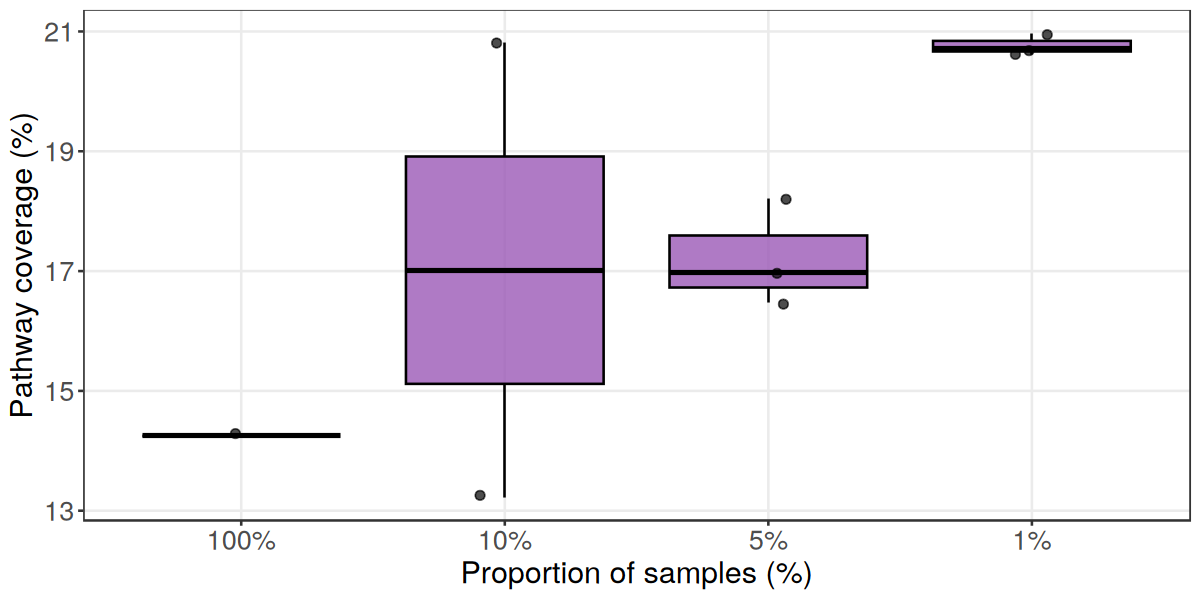

In [50]:
options(repr.plot.width = 15, repr.plot.height = 7)

results_df$coverage_label <- factor(
  paste0(results_df$coverage_pct, "%"),
  levels = c("100%", "10%", "5%", "1%")
)

options(repr.plot.width = 10, repr.plot.height = 5)

ggplot(results_df, aes(x = coverage_label, y = prop_pathway * 100)) +
  geom_boxplot(fill = "#9b59b6", colour = "black", alpha = 0.8,
               outlier.shape = 16, outlier.size = 2) +
  geom_jitter(width = 0.1, size = 2, colour = "black", alpha = 0.7) +
  labs(
    x = "Proportion of samples (%)",
    y = "Pathway coverage (%)"
  ) +
  theme_bw(base_size = 12) +
  theme(
    plot.title       = element_text(hjust = 0.5, size = 11),
    panel.grid.minor = element_blank(),
    legend.position  = "none",
    axis.title       = element_text(size = 18),
    axis.text        = element_text(size = 16)
  )

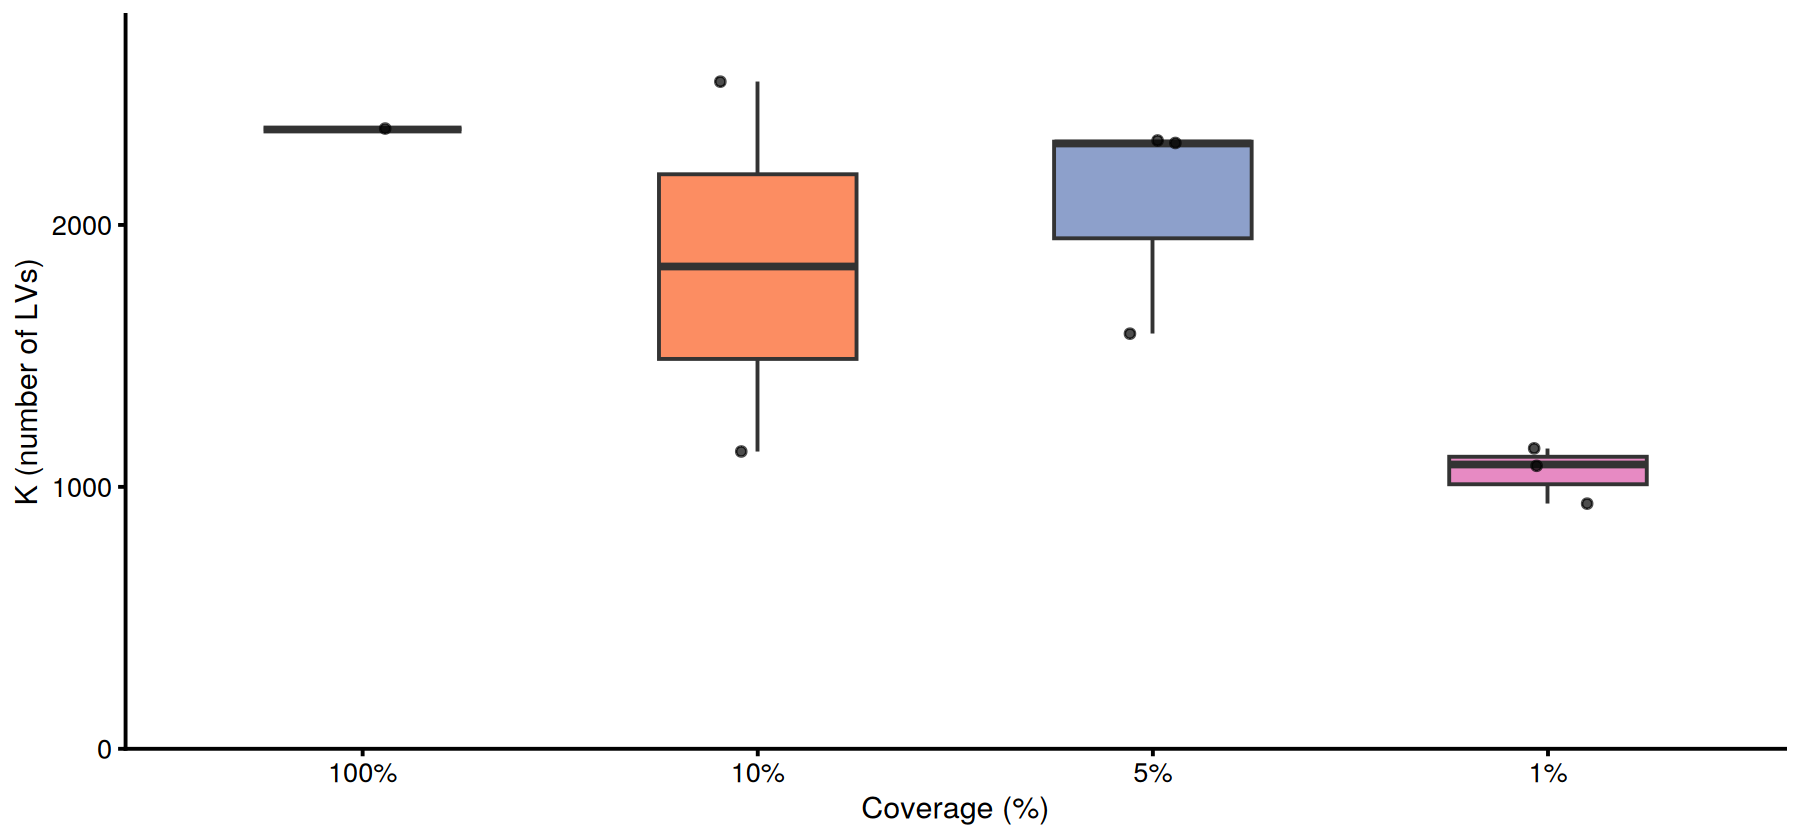

In [51]:
options(repr.plot.width = 15, repr.plot.height = 7)

results_df$coverage_label <- factor(
  paste0(results_df$coverage_pct, "%"),
  levels = c("100%", "10%", "5%", "1%")
)

ggplot(results_df, aes(x = coverage_label, y = n_lvs, fill = coverage_label)) +
  geom_boxplot(width = 0.5, outlier.shape = 21, outlier.size = 2) +
  geom_jitter(width = 0.1, size = 2, alpha = 0.7) +
  scale_fill_brewer(palette = "Set2") +
  scale_y_continuous(limits = c(0, NA), expand = expansion(mult = c(0, 0.1))) +
  labs(
    x     = "Coverage (%)",
    y     = "K (number of LVs)"
  ) +
  theme_classic(base_size = 18) +
  theme(
    legend.position  = "none",
    plot.title       = element_text(size = 20),
    axis.title       = element_text(size = 18),
    axis.text        = element_text(size = 16)
  )